In [22]:
# Load trained model and required libraries

import os

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

MODEL_PATH = "../models/telco_churn_model.joblib"

model = joblib.load(MODEL_PATH)

print("Model loaded successfully.")

Model loaded successfully.


In [23]:
# Load held-out test set

X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print(f"Test features: {X_test.shape}")
print(f"Test target: {y_test.shape}")

Test features: (1057, 45)
Test target: (1057,)


In [24]:
# Generate predictions and churn probabilities on the test set

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

In [25]:
# Compute core classification metrics

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_proba),
    "PR-AUC": average_precision_score(y_test, y_proba)
}

metrics_df = (
    pd.DataFrame(
        metrics.items(),
        columns=["Metric", "Score"]
    )
)

metrics_df["Score"] = metrics_df["Score"].round(4)

metrics_df

,Metric,Score
0,Accuracy,0.8023
1,Precision,0.6731
2,Recall,0.4982
3,F1,0.5726
4,ROC-AUC,0.8424
5,PR-AUC,0.6710


In [26]:
# Per-class precision/recall/F1 breakdown

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87       776
           1       0.67      0.50      0.57       281

    accuracy                           0.80      1057
   macro avg       0.75      0.71      0.72      1057
weighted avg       0.79      0.80      0.79      1057



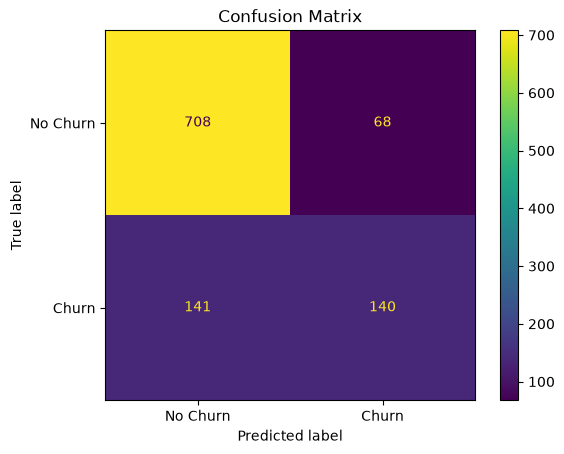

In [27]:
# Visualize true vs. predicted labels

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

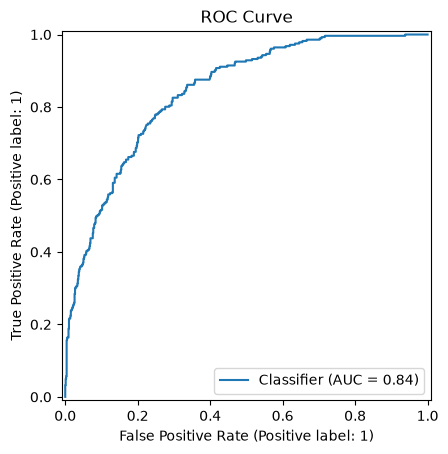

In [28]:
# Plot ROC curve to assess separability across thresholds

RocCurveDisplay.from_predictions(
    y_test,
    y_proba
)

plt.title("ROC Curve")
plt.show()

In [29]:
# Extract built-in feature importances for tree-based estimators

model_estimator = model

if hasattr(model_estimator, "named_steps"):
    model_estimator = model_estimator.named_steps["model"]

if hasattr(model_estimator, "feature_importances_"):

    importance_df = pd.DataFrame({
        "feature": X_test.columns,
        "importance": model_estimator.feature_importances_
    })

    importance_df = (
        importance_df
        .sort_values("importance", ascending=False)
        .head(15)
    )

    importance_df

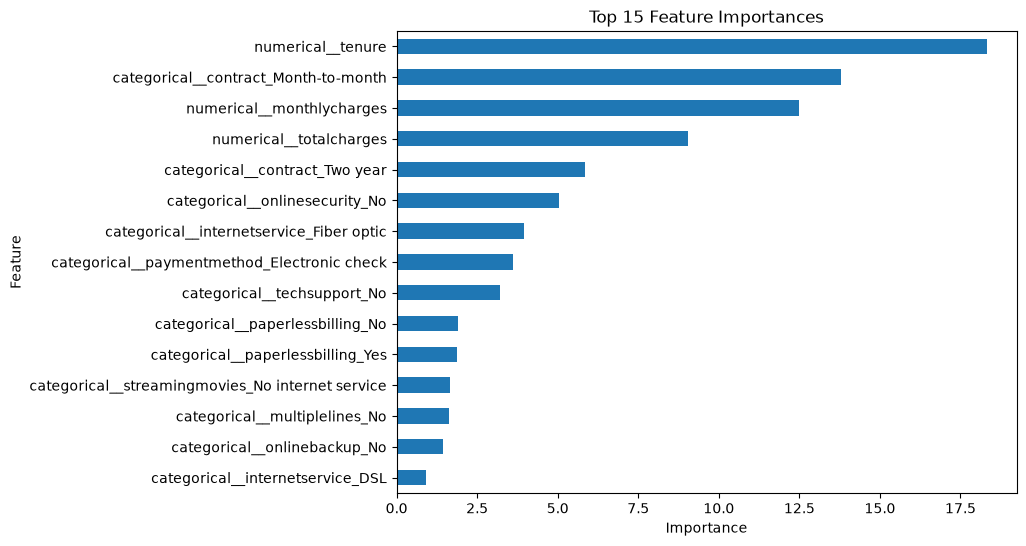

In [30]:
# Plot top 15 most important features

importance_df.sort_values("importance").plot(
    x="feature",
    y="importance",
    kind="barh",
    legend=False,
    figsize=(8, 6)
)

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [31]:
# Fallback: use absolute coefficient magnitude for linear estimators

if hasattr(model_estimator, "coef_"):

    importance_df = pd.DataFrame({
        "feature": X_test.columns,
        "importance": np.abs(model_estimator.coef_[0])
    })

    importance_df = (
        importance_df
        .sort_values("importance", ascending=False)
        .head(15)
    )

    importance_df

In [32]:
# SHAP values via tree-specific explainer (fast, exact for tree models)

explainer = shap.TreeExplainer(model_estimator)

shap_values = explainer.shap_values(X_test)

In [33]:
# SHAP values via general-purpose explainer (model-agnostic)

explainer = shap.Explainer(model_estimator, X_test)

shap_values = explainer(X_test)

 92%|==================  | 975/1057 [00:13<00:01]       

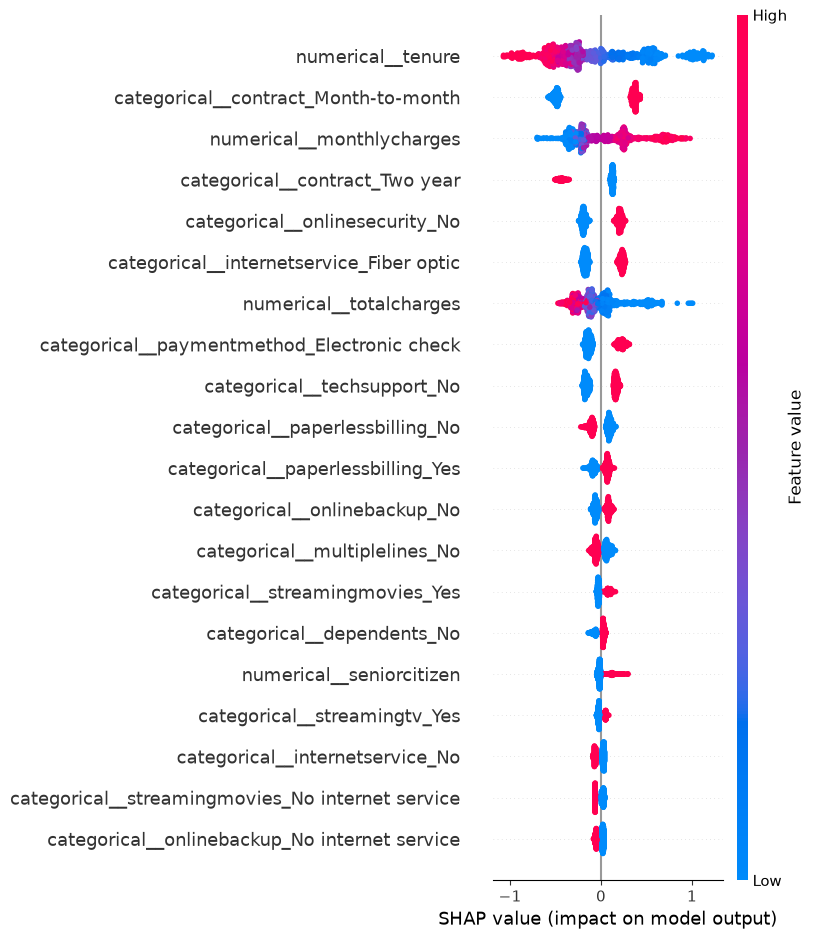

In [34]:
# Show feature impact direction and magnitude across all samples

shap.summary_plot(
    shap_values,
    X_test,
    show=True
)

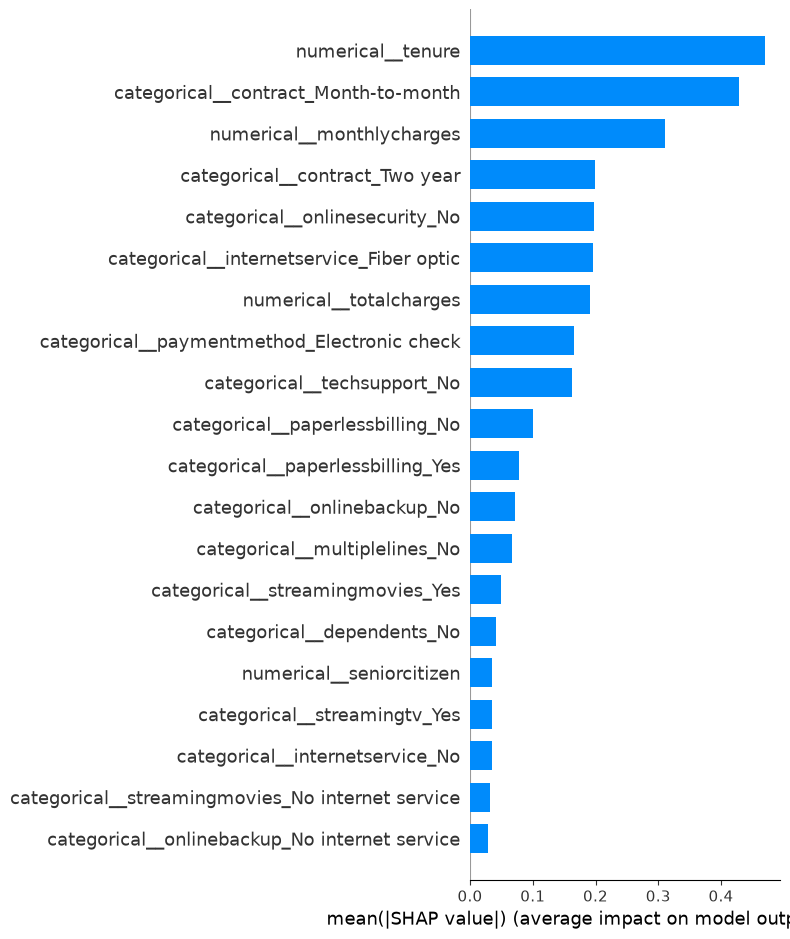

In [35]:
# Show mean absolute SHAP value ranking per feature

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=True
)

In [36]:
# Error analysis

error_analysis = X_test.copy()

error_analysis["actual"] = y_test.values
error_analysis["predicted"] = y_pred
error_analysis["churn_probability"] = y_proba

error_analysis["error"] = (
    error_analysis["actual"] != error_analysis["predicted"]
)

errors = error_analysis[
    error_analysis["error"]
].copy()

print(f"Total errors: {len(errors)}")
print(f"Error rate: {len(errors) / len(X_test):.2%}")

Total errors: 209
Error rate: 19.77%


In [37]:
# separate false positive from false negative

false_positives = error_analysis[
    (error_analysis["actual"] == 0) &
    (error_analysis["predicted"] == 1)
]

false_negatives = error_analysis[
    (error_analysis["actual"] == 1) &
    (error_analysis["predicted"] == 0)
]

print(f"False positives: {len(false_positives)}")
print(f"False negatives: {len(false_negatives)}")

False positives: 68
False negatives: 141


In [38]:
# Most uncertain prediction

error_analysis["uncertainty"] = np.abs(
    error_analysis["churn_probability"] - 0.5
)

uncertain_cases = (
    error_analysis
    .sort_values("uncertainty")
    .head(10)
)

uncertain_cases[
    ["actual", "predicted", "churn_probability"]
]

,actual,predicted,churn_probability
279,0,1,0.501034
954,0,0,0.497755
161,1,0,0.497417
131,0,1,0.502752
911,0,0,0.496361
119,1,1,0.504318
894,0,0,0.495370
700,0,1,0.505139
314,1,1,0.505387
274,1,1,0.505816


In [39]:
# Load prior model comparison results, if available

comparison_path = "../models/model_comparison.csv"

if os.path.exists(comparison_path):
    comparison = pd.read_csv(comparison_path)
    comparison

In [40]:
# Summarize final model performance in a single table

final_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Final Model": [
        metrics["Accuracy"],
        metrics["Precision"],
        metrics["Recall"],
        metrics["F1"],
        metrics["ROC-AUC"],
        metrics["PR-AUC"]
    ]
})

final_comparison["Final Model"] = (
    final_comparison["Final Model"].round(4)
)

final_comparison

,Metric,Final Model
0,Accuracy,0.8023
1,Precision,0.6731
2,Recall,0.4982
3,F1,0.5726
4,ROC-AUC,0.8424
5,PR-AUC,0.6710


In [41]:
# Print key headline metrics for quick reference

print(
    f"Final model ROC-AUC: {metrics['ROC-AUC']:.4f}"
)

print(
    f"Final model Recall: {metrics['Recall']:.4f}"
)

print(
    f"Final model F1: {metrics['F1']:.4f}"
)

Final model ROC-AUC: 0.8424
Final model Recall: 0.4982
Final model F1: 0.5726
